In [19]:
import pandas as pd
import numpy as np
from skimage.metrics import structural_similarity as ssim
from scipy.stats import gaussian_kde

import matplotlib.pyplot as plt

In [20]:
color_map = {
    "progenitor": "#6abd12",
    "MBO": "#bce590",

    "VZ_neuroblast_1": "#facc15",
    "VZ_neuroblast_2": "#fde047",
    "VZ_neuroblast_3": "#fef08a",

    "NTZ_neuroblast_1": "#7d5207",
    "NTZ_neuroblast_2": "#b39054",
    "NTZ_neuroblast_3": "#ecd09f",

    "GCP": "#7f1d1d",
    "GC_diff_1": "#f76161",
    "GC_diff_2": "#ff9f9f",
    "GC_defined": "#ffd5d5",

    "GCP/UBCP": "#f27500",
    "GC/UBC_diff": "#fb9f4a",
    "UBC_diff": "#f7b272",
    "UBC_defined": "#fdc999",

    "Purkinje_diff": "#0a229b",
    "Purkinje_defined": "#90a2f2",
    "Purkinje_maturing": "#cbd4f9",

    "interneuron_diff": "#069372",
    "interneuron_defined": "#7cd9c3",
    "GABA_DN_defined": "#c2ece2",

    "glut_DN_defined": "#ae3970",
    "isth_N_diff": "#fdb8e9",
    "isth_N_defined": "#ffe1f7",

    "glioblast": "#550584",
    "oligo_progenitor": "#8c2ebf",
    "oligodendrocyte": "#c38ce3",
    "astrocyte": "#d7c8f0",
    
    "meningeal": "#1a1a1a",
    "parabrachial": "#4d4d4d"
}

In [21]:
def make_density_map(
    df_sub,
    x_col="MDS_1",
    y_col="MDS_2",
    grid_size=50,
    coord_range=(-1, 1),
    bw_method=None,
    min_cells=3
):

    use = df_sub[
        df_sub[x_col].between(coord_range[0], coord_range[1])
        & df_sub[y_col].between(coord_range[0], coord_range[1])
    ].dropna(subset=[x_col, y_col])

    if len(use) < min_cells:
        return np.full(
            (grid_size, grid_size),
            np.nan
        )

    x_grid = np.linspace(
        coord_range[0],
        coord_range[1],
        grid_size
    )

    y_grid = np.linspace(
        coord_range[0],
        coord_range[1],
        grid_size
    )

    xx, yy = np.meshgrid(x_grid, y_grid)

    coordinates = np.vstack([
        use[x_col].to_numpy(),
        use[y_col].to_numpy()
    ])

    try:
        kde = gaussian_kde(
            coordinates,
            bw_method=bw_method
        )

        grid_positions = np.vstack([
            xx.ravel(),
            yy.ravel()
        ])

        density = kde(
            grid_positions
        ).reshape(grid_size, grid_size)

    except (np.linalg.LinAlgError, ValueError):
        return np.full(
            (grid_size, grid_size),
            np.nan
        )

    density_sum = density.sum()

    if density_sum > 0:
        density = density / density_sum

    return density

In [22]:
def make_annotation_density_maps(
    df_stage,
    annotation_col="annotation",
    x_col="MDS_1",
    y_col="MDS_2",
    annotations=None,
    grid_size=50,
    coord_range=(-1, 1),
    bw_method=None,
    min_cells=3
):
    if annotations is None:
        annotations = sorted(
            df_stage[annotation_col].dropna().unique()
        )

    density_maps = {}
    cell_counts = {}

    for anno in annotations:
        df_sub = df_stage[
            df_stage[annotation_col] == anno
        ]

        cell_counts[anno] = len(df_sub)

        if len(df_sub) == 0:
            density_maps[anno] = None
            continue

        density_maps[anno] = make_density_map(
            df_sub=df_sub,
            x_col=x_col,
            y_col=y_col,
            grid_size=grid_size,
            coord_range=coord_range,
            bw_method=bw_method,
            min_cells=min_cells
        )

    return density_maps, cell_counts

In [23]:
def calculate_s_color_weighted(
    maps_a,
    maps_b,
    counts_a,
    counts_b,
    annotations=None
):
    if annotations is None:
        annotations = sorted(
            set(maps_a.keys()) | set(maps_b.keys())
        )

    total_a = sum(counts_a.values())
    total_b = sum(counts_b.values())

    scores = {}
    weights = {}

    for anno in annotations:
        map_a = maps_a.get(anno)
        map_b = maps_b.get(anno)

        count_a = counts_a.get(anno, 0)
        count_b = counts_b.get(anno, 0)

        prop_a = count_a / total_a if total_a > 0 else 0
        prop_b = count_b / total_b if total_b > 0 else 0

        weights[anno] = (prop_a + prop_b) / 2

        if map_a is None or map_b is None:
            scores[anno] = 0.0
            continue

        if np.isnan(map_a).any() or np.isnan(map_b).any():
            scores[anno] = 0.0
            continue

        data_range = max(map_a.max(), map_b.max()) - min(
            map_a.min(), map_b.min()
        )

        if data_range == 0:
            scores[anno] = 1.0
        else:
            scores[anno] = float(
                ssim(
                    map_a,
                    map_b,
                    data_range=data_range
                )
            )

    score_array = np.array([
        scores[a] for a in annotations
    ])

    weight_array = np.array([
        weights[a] for a in annotations
    ])

    if weight_array.sum() > 0:
        weight_array = weight_array / weight_array.sum()

    s_color = np.sum(score_array * weight_array)

    return s_color, scores, weights

In [24]:
def compute_s_color_for_stage_pair(
    stage_pair,
    mds_dir="mds_capped",
    grid_size=50,
    coord_range=(-1, 1),
    min_cells=3,
):
    df = pd.read_csv(f"{mds_dir}/mds_sampling_{stage_pair[0]}_{stage_pair[1]}.csv")

    stage_pairs = [
        (stage_pair[0], stage_pair[1]),
        (stage_pair[0], f"{stage_pair[0]}{stage_pair[1]}"),
    ]

    results = []
    for stage_a, stage_b in stage_pairs:
        df_a = df[df["stage"] == stage_a]
        df_b = df[df["stage"] == stage_b]

        annotation_union = sorted(
            set(df_a["annotation"].dropna()) | set(df_b["annotation"].dropna())
        )

        maps_a, counts_a = make_annotation_density_maps(
            df_a,
            annotations=annotation_union,
            annotation_col="annotation",
            x_col="MDS_1",
            y_col="MDS_2",
            grid_size=grid_size,
            coord_range=coord_range,
            min_cells=min_cells,
        )
        maps_b, counts_b = make_annotation_density_maps(
            df_b,
            annotations=annotation_union,
            annotation_col="annotation",
            x_col="MDS_1",
            y_col="MDS_2",
            grid_size=grid_size,
            coord_range=coord_range,
            min_cells=min_cells,
        )

        s_color, anno_scores, anno_weights = calculate_s_color_weighted(
            maps_a=maps_a,
            maps_b=maps_b,
            counts_a=counts_a,
            counts_b=counts_b,
            annotations=annotation_union,
        )

        results.append({
            "stage_a": stage_a,
            "stage_b": stage_b,
            "S_color": s_color,
            "annotation_scores": anno_scores,
            "annotation_weights": anno_weights,
            "counts_a": counts_a,
            "counts_b": counts_b,
        })

    return results


In [26]:
stage_pair_list = [
    ("E11.5", "E12.5"),
    ("E12.5", "E11.5"),
    ("E12.5", "E13.5"),
    ("E13.5", "E12.5"),
    ("E13.5", "E14.5"),
    ("E14.5", "E13.5"),
    ("E14.5", "E15.5"),
    ("E15.5", "E14.5"),
    ("E15.5", "E17.5"),
    ("E17.5", "E15.5"),
    ("E17.5", "P0"),
    ("P0", "E17.5"),
    ("P0","P4"),
    ("P4","P0"),
    ("P4","P7"),
    ("P7","P4"),
    #("P7","P14"),
    #("P14","P7"),
    #("P14","adult"),
    #("adult","P14")
]

In [41]:
all_results = {}
for sp in stage_pair_list:
    key = f"{sp[1]}→{sp[0]}"
    all_results[key] = compute_s_color_for_stage_pair(sp)

all_results.keys()

dict_keys(['E12.5→E11.5', 'E11.5→E12.5', 'E13.5→E12.5', 'E12.5→E13.5', 'E14.5→E13.5', 'E13.5→E14.5', 'E15.5→E14.5', 'E14.5→E15.5', 'E17.5→E15.5', 'E15.5→E17.5', 'P0→E17.5', 'E17.5→P0', 'P4→P0', 'P0→P4', 'P7→P4', 'P4→P7'])

In [42]:
def build_delta_table(all_results):
    
    rows = []
    for key, results in all_results.items():
        s_a = results[0]["S_color"]
        s_b = results[1]["S_color"]
        rows.append({
            "stage_pair": key,
            "S_color_a": s_a,
            "S_color_b": s_b,
            "delta": s_b - s_a,
        })

    return pd.DataFrame(rows)


delta_df = build_delta_table(all_results)
delta_df

,stage_pair,S_color_a,S_color_b,delta
0,E12.5→E11.5,0.693543,0.782114,0.088571
1,E11.5→E12.5,0.646555,0.673953,0.027398
2,E13.5→E12.5,0.797934,0.898003,0.100069
3,E12.5→E13.5,0.792950,0.798050,0.005101
4,E14.5→E13.5,0.823972,0.820061,-0.003911
5,E13.5→E14.5,0.828051,0.834447,0.006396
6,E15.5→E14.5,0.865577,0.944264,0.078687
7,E14.5→E15.5,0.872968,0.879785,0.006817
8,E17.5→E15.5,0.835654,0.821514,-0.014139
9,E15.5→E17.5,0.835310,0.893210,0.057899


In [43]:
even_rows = delta_df.iloc[0::2]
odd_rows = delta_df.iloc[1::2]


delta_df_odd = pd.concat([odd_rows]).reset_index(drop=True)
delta_df_even = pd.concat([even_rows]).reset_index(drop=True)

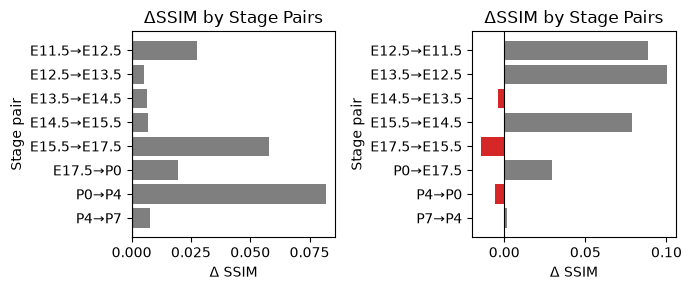

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(7, 3))
axes = axes.ravel()

for ax, delta in zip(axes, (delta_df_odd, delta_df_even)):
    colors = ["tab:grey" if d >= 0 else "tab:red" for d in delta["delta"]]
    ax.barh(delta["stage_pair"], delta["delta"], color=colors)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_xlabel("Δ SSIM")
    ax.set_ylabel("Stage pair")
    ax.set_title("ΔSSIM by Stage Pairs")
    ax.invert_yaxis()

plt.tight_layout()
plt.savefig("mds_capped/delta_s_color.png", dpi=150)
plt.show()

In [47]:
for _, row in delta_df.iterrows():

    before = row["S_color_a"]
    after = row["S_color_b"]
    delta = row["delta"]

    plt.figure(figsize=(2.3, 3.2))

    bars = plt.bar(
        ["MDS-before", "MDS-after"],
        [before, after],
        color="dimgray")

    for bar, value in zip(bars, [before, after]):
        plt.text(
            bar.get_x() + bar.get_width()/2,
            value + 0.005,
            f"{value:.3f}",
            ha="center",
            fontsize=9
        )

    plt.title(
        f"ΔSSIM = {delta:+.4f}",
        fontsize=11
    )

    plt.ylabel("S-score", fontsize=10)
    plt.ylim(0.4, 1.0)

    plt.xticks(
        rotation=35,
        ha="right",
        fontsize=9
    )

    plt.title(
    f'ΔSSIM = {delta:+.4f}',
    fontsize=11
    )

    plt.yticks(fontsize=9)

    plt.tight_layout()

    stage_name = row["stage_pair"].replace("→", "_to_")

    plt.savefig(
        f"SSIM_{stage_name}.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.close()